<a href="https://colab.research.google.com/github/luisalejandrojaramillo/MIAR_Algoritmos_de_optimizacion/blob/main/SEMINARIO/Seminario_Algoritmos_Jaramillo_Castaneda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmos de optimización - Seminario<br>
Nombre y Apellidos:   <br>
* Luis Alejandro Jaramillo
* Carlos Andres Castañeda

Problema:
>3. Combinar cifras y operaciones

Descripción del problema:

* El problema consiste en analizar el siguiente problema y diseñar un algoritmo que lo resuelva.
* Disponemos de las 9 cifras del 1 al 9 (excluimos el cero) y de los 4 signos básicos de las
operaciones fundamentales: suma(+), resta(-), multiplicación(*) y división(/)
* Debemos combinarlos alternativamente sin repetir ninguno de ellos para obtener una
cantidad dada. Un ejemplo sería para obtener el 4:
4+2-6/3*1 = 4
* Debe analizarse el problema para encontrar todos los valores enteros posibles planteando las
siguientes cuestiones:
  - ¿Qué valor máximo y mínimo se pueden obtener según las condiciones del problema?
  - ¿Es posible encontrar todos los valores enteros posibles entre dicho mínimo y máximo ?
* Nota: Es posible usar la función de python “eval” para evaluar una expresión

....

(*) La respuesta es obligatoria
                                        

In [ ]:
import itertools
import math

# ─────────────────────────────────────────────
# PARÁMETROS DEL PROBLEMA
# ─────────────────────────────────────────────
nums       = ('1','2','3','4','5','6','7','8','9')  # 9 dígitos disponibles
operations = ('+', '-', '/', '*')                   # 4 operadores disponibles

# ─────────────────────────────────────────────
# SIN RESTRICCIONES (repetición permitida)
# ─────────────────────────────────────────────
# Posiciones: n1 op1 n2 op2 n3 op3 n4 op4 n5
# Si permitiéramos repetir: 9^5 * 4^4
posibilidades_sin_restriccion = (9**5) * (4**4)
print(f"Sin restricciones (repetición permitida): {posibilidades_sin_restriccion:,} combinaciones")

# ─────────────────────────────────────────────
# CON RESTRICCIONES (sin repetición)
# ─────────────────────────────────────────────
# Variaciones de 9 números tomados de 5 en 5: P(9,5) = 9!/(9-5)! = 15120
variaciones_numeros = math.factorial(9) // math.factorial(9 - 5)

# Permutaciones de los 4 operadores (todos usados una vez): 4! = 24
permutaciones_operadores = math.factorial(4)

posibilidades_con_restriccion = variaciones_numeros * permutaciones_operadores
print(f"Con restricciones (sin repetición):        {posibilidades_con_restriccion:,} combinaciones")
print(f"  → Variaciones P(9,5) = {variaciones_numeros:,}  ×  Permutaciones 4! = {permutaciones_operadores}")
print(f"  → {variaciones_numeros} × {permutaciones_operadores} = {posibilidades_con_restriccion:,}")

# Verificación con itertools
total_verificado = sum(1 for _ in itertools.permutations(nums, 5)) * sum(1 for _ in itertools.permutations(operations))
print(f"\nVerificación con itertools: {total_verificado:,} ✓")

Sin restricciones (repetición permitida): 15,116,544 combinaciones
Con restricciones (sin repetición):        362,880 combinaciones
  → Variaciones P(9,5) = 15,120  ×  Permutaciones 4! = 24
  → 15120 × 24 = 362,880

Verificación con itertools: 362,880 ✓


(*)¿Cuantas posibilidades hay sin tener en cuenta las restricciones?<br>



¿Cuantas posibilidades hay teniendo en cuenta todas las restricciones.




**Respuesta:**

**Sin tener en cuenta las restricciones** (permitiendo repetir números y operadores):
- Tenemos 5 posiciones para números con 9 opciones cada una: $9^5 = 59.049$
- Tenemos 4 posiciones para operadores con 4 opciones cada una: $4^4 = 256$
- Total: $9^5 \times 4^4 = \mathbf{15.116.544}$ combinaciones

**Teniendo en cuenta todas las restricciones** (sin repetición, usando exactamente los 4 operadores y 5 números distintos):
- Los números se escogen como **variaciones sin repetición** de 9 tomados de 5 en 5:
$$V(9,5) = \frac{9!}{(9-5)!} = \frac{9!}{4!} = 15.120$$
- Los operadores se distribuyen en **permutaciones** de los 4 signos (sin repetición):
$$P(4) = 4! = 24$$
- Total: $15.120 \times 24 = \mathbf{362.880}$ combinaciones posibles

De todas ellas, **90.000** producen un resultado entero (lo que se demostrará en las siguientes secciones).

In [ ]:
# Verificación directa contando expresiones con resultado entero
expresiones_enteras = []
for op_sec in itertools.permutations(operations):
    for num_sec in itertools.permutations(nums, 5):
        expr = num_sec[0] + op_sec[0] + num_sec[1] + op_sec[1] + num_sec[2] + op_sec[2] + num_sec[3] + op_sec[3] + num_sec[4]
        resultado = eval(expr)
        if resultado == int(resultado):
            expresiones_enteras.append(expr)

print(f"Total expresiones con resultado entero: {len(expresiones_enteras):,}")
print(f"Total expresiones posibles (con restricciones): {posibilidades_con_restriccion:,}")

Total expresiones con resultado entero: 90,000
Total expresiones posibles (con restricciones): 362,880


Modelo para el espacio de soluciones<br>
(*) ¿Cual es la estructura de datos que mejor se adapta al problema? Argumentalo.(Es posible que hayas elegido una al principio y veas la necesidad de cambiar, arguentalo)


**Respuesta:**

La estructura de datos que mejor se adapta a este problema es el **diccionario (dict)** de Python, aunque el proceso de construcción pasa por varios pasos:

1. **Listas** durante la generación: Se usan listas para ir construyendo cada expresión paso a paso, ya que permiten modificación, inserción y acceso por índice.

2. **Tuplas** para las permutaciones: Las secuencias de números y operadores generadas con `itertools.permutations` son inmutables, lo que las hace eficientes para iterar.

3. **Diccionario como estructura final** (la más adecuada): Un diccionario donde las **claves son los resultados enteros** y los **valores son las listas de expresiones** que producen ese resultado. Esto permite:
   - Encontrar el máximo y mínimo en O(1): `max(dct.keys())`
   - Verificar si todos los enteros del intervalo están cubiertos: `len(dct) == max - min + 1`
   - Consultar qué expresiones producen un valor dado directamente

Esta elección se justifica porque el objetivo final no es solo encontrar las expresiones, sino **agruparlas por resultado** para responder las preguntas del problema de forma eficiente.

In [ ]:
# Construimos el diccionario de expresiones agrupadas por resultado
dct_expresiones = {}

for expr in expresiones_enteras:
    resultado = int(eval(expr))
    if resultado not in dct_expresiones:
        dct_expresiones[resultado] = []
    dct_expresiones[resultado].append(expr)

# Ordenamos por clave (resultado)
dct_expresiones = dict(sorted(dct_expresiones.items()))

print(f"Número de valores enteros distintos obtenibles: {len(dct_expresiones)}")
print(f"Valor mínimo: {min(dct_expresiones.keys())}")
print(f"Valor máximo: {max(dct_expresiones.keys())}")
print(f"\nEjemplo – expresiones que dan 77 (máximo): {dct_expresiones[77][:3]}")
print(f"Ejemplo – expresiones que dan -69 (mínimo): {dct_expresiones[-69][:3]}")

Número de valores enteros distintos obtenibles: 147
Valor mínimo: -69
Valor máximo: 77

Ejemplo – expresiones que dan 77 (máximo): ['7+8/1*9-2', '7+9/1*8-2', '7+8*9-2/1']
Ejemplo – expresiones que dan -69 (mínimo): ['1+4/2-8*9', '1+4/2-9*8', '1+6/3-8*9']


Según el modelo para el espacio de soluciones<br>
(*)¿Cual es la función objetivo?

(*)¿Es un problema de maximización o minimización?

**Respuesta:**

**Función objetivo:**

La función objetivo depende del sub-problema que estemos resolviendo:

- Para la **construcción del espacio de posibilidades**: la función objetivo es $f(expr) = eval(expr) \in \mathbb{Z}$, es decir, evaluar si una expresión produce un número entero. Solo se retienen las que cumplen esta condición.

- Para la **búsqueda del máximo o mínimo**: $f(expr) = eval(expr)$, y buscamos maximizar o minimizar dicho valor sujeto a las restricciones del problema (sin repetición de dígitos ni operadores, alternando cifra-operador-cifra...).

**¿Es un problema de maximización o minimización?**

Es **ambas cosas**, dependiendo de la pregunta. Sin embargo, en su esencia este es principalmente un **problema de búsqueda y exploración del espacio de soluciones**, no un problema de optimización clásico. El objetivo real es:
1. Encontrar el **máximo** valor entero alcanzable.
2. Encontrar el **mínimo** valor entero alcanzable.
3. Verificar que **todos los enteros** en ese intervalo son alcanzables.

Al no existir una función continua que derivar ni un gradiente que seguir, los algoritmos más adecuados son los de exploración exhaustiva (fuerza bruta), ramificación y poda, y búsquedas heurísticas.

In [ ]:
# Demostración de la función objetivo
def funcion_objetivo(expr):
    """
    Evalúa una expresión y retorna su valor si es entero, None en caso contrario.
    Esta es la función objetivo del problema de construcción del espacio de soluciones.
    """
    try:
        resultado = eval(expr)
        if resultado == int(resultado):
            return int(resultado)
    except ZeroDivisionError:
        pass
    return None

# Ejemplo
ejemplos = ["7+8*9-2/1", "1+4/2-8*9", "3+5-1*2/4"]
for e in ejemplos:
    r = funcion_objetivo(e)
    print(f"  eval('{e}') = {eval(e):.4f}  →  entero: {r}")

# Valor máximo y mínimo
valores = [int(eval(e)) for e in expresiones_enteras]
print(f"\nValor MÁXIMO alcanzable: {max(valores)}")
print(f"Valor MÍNIMO alcanzable: {min(valores)}")

  eval('7+8*9-2/1') = 77.0000  →  entero: 77
  eval('1+4/2-8*9') = -69.0000  →  entero: -69
  eval('3+5-1*2/4') = 7.5000  →  entero: None

Valor MÁXIMO alcanzable: 77
Valor MÍNIMO alcanzable: -69


Diseña un algoritmo para resolver el problema por fuerza bruta

**Respuesta – Algoritmo por fuerza bruta:**

El algoritmo de fuerza bruta genera **todas las combinaciones posibles** de números (variaciones sin repetición de 5 de los 9 dígitos) y operadores (permutaciones de los 4 signos), las ensambla como expresión matemática en formato cadena, las evalúa con `eval()` y retiene únicamente las que producen un resultado entero.

**Pseudocódigo:**
```
Para cada permutación de operadores (op1, op2, op3, op4):
    Para cada variación de 5 números distintos de {1..9}:
        Construir expresión: n1 op1 n2 op2 n3 op3 n4 op4 n5
        Si eval(expresión) es entero:
            Añadir a la lista de soluciones
```

La función ya fue implementada en la celda anterior. A continuación se presentan los resultados:

In [ ]:
# ─────────────────────────────────────────────────────────────────
# ALGORITMO POR FUERZA BRUTA – Implementación formal
# ─────────────────────────────────────────────────────────────────
import itertools
import time

def fuerza_bruta(nums=('1','2','3','4','5','6','7','8','9'),
                 ops=('+', '-', '/', '*')):
    """
    Genera todas las secuencias operacionales válidas (resultado entero).

    Parámetros:
        nums: dígitos disponibles (sin el 0 por defecto)
        ops:  operadores disponibles

    Retorna:
        Lista de cadenas que representan expresiones con resultado entero.
    """
    soluciones = []
    n_ops = len(ops)  # k = número de operadores = número de "huecos"
    k_nums = n_ops + 1  # necesitamos un número más que operadores

    for perm_ops in itertools.permutations(ops):           # 4! = 24 iteraciones
        for perm_nums in itertools.permutations(nums, k_nums):  # P(9,5) = 15120
            # Intercalar: n op n op n op n op n
            expr = ''.join(
                c for par in zip(perm_nums, perm_ops) for c in par
            ) + perm_nums[-1]

            try:
                resultado = eval(expr)
                if resultado == int(resultado):
                    soluciones.append(expr)
            except ZeroDivisionError:
                pass  # ignorar divisiones por cero

    return soluciones

# Ejecutamos y medimos tiempo
t0 = time.time()
soluciones_fb = fuerza_bruta()
t1 = time.time()

print(f"Expresiones con resultado entero: {len(soluciones_fb):,}")
print(f"Tiempo de ejecución:              {t1 - t0:.3f} segundos")
print(f"\nPrimeras 5 expresiones: {soluciones_fb[:5]}")
print(f"Últimas  5 expresiones: {soluciones_fb[-5:]}")

Expresiones con resultado entero: 90,000
Tiempo de ejecución:              4.097 segundos

Primeras 5 expresiones: ['1+2-3/4*8', '1+2-3/6*4', '1+2-3/6*8', '1+2-3/9*6', '1+2-4/3*6']
Últimas  5 expresiones: ['9*8/6-7+1', '9*8/6-7+2', '9*8/6-7+3', '9*8/6-7+4', '9*8/6-7+5']


Calcula la complejidad del algoritmo por fuerza bruta

**Respuesta – Complejidad del algoritmo por fuerza bruta:**

La complejidad se descompone en dos factores independientes:

**1. Permutaciones de operadores** (todos los $n$ operadores, sin repetición):
$$P(n) = n!$$
Para $n = 4$ operadores: $4! = 24$ iteraciones.

**2. Variaciones sin repetición de números** (elegir $k = n+1$ números de $m$ disponibles):
$$V(m, k) = \frac{m!}{(m-k)!}$$
Para $m = 9$ números, $k = 5$: $V(9,5) = \frac{9!}{4!} = 15.120$ iteraciones.

**Complejidad total:**
$$\mathcal{O}\left(n! \cdot \frac{m!}{(m-k)!}\right) = \mathcal{O}\left(n! \cdot V(m, n+1)\right)$$

Para los valores concretos del problema: $24 \times 15.120 = \mathbf{362.880}$ operaciones principales.

Cada iteración realiza un `eval()` que tiene coste constante O(1) para expresiones de longitud fija, por lo que la complejidad final es:
$$\mathcal{O}(362.880) \equiv \mathcal{O}(n! \cdot V(m, n+1))$$

Esta complejidad crece **factorialmente** con el número de operadores y de forma superlineal con el número de dígitos disponibles, lo que hace que la fuerza bruta sea inviable para problemas de mayor tamaño.

In [ ]:
# Verificación de la complejidad teórica
import math

def calcular_complejidad(m, n):
    """
    Calcula el número de operaciones del algoritmo de fuerza bruta.
    m = cantidad de números disponibles
    n = cantidad de operadores
    """
    k = n + 1  # números a usar = operadores + 1
    perm_ops  = math.factorial(n)
    var_nums  = math.factorial(m) // math.factorial(m - k)
    total     = perm_ops * var_nums
    return perm_ops, var_nums, total

# Tabla de complejidad para distintos tamaños
print(f"{'m (nums)':>10} {'n (ops)':>8} {'P(ops)':>8} {'V(nums)':>10} {'Total':>12}")
print("-" * 55)
for m, n in [(9,4), (10,4), (11,4), (12,4), (9,5), (10,5)]:
    p, v, t = calcular_complejidad(m, n)
    print(f"{m:>10} {n:>8} {p:>8,} {v:>10,} {t:>12,}")

# Resultado del problema actual
p, v, t = calcular_complejidad(9, 4)
print(f"\nProblema actual (m=9, n=4): {p} × {v} = {t:,} operaciones")

  m (nums)  n (ops)   P(ops)    V(nums)        Total
-------------------------------------------------------
         9        4       24     15,120      362,880
        10        4       24     30,240      725,760
        11        4       24     55,440    1,330,560
        12        4       24     95,040    2,280,960
         9        5      120     60,480    7,257,600
        10        5      120    151,200   18,144,000

Problema actual (m=9, n=4): 24 × 15120 = 362,880 operaciones


(*)Diseña un algoritmo que mejore la complejidad del algortimo por fuerza bruta. Argumenta porque crees que mejora el algoritmo por fuerza bruta

**Respuesta – Algoritmo mejorado: Ramificación y Poda con Búsqueda por Patrones**

**Idea principal:**

Tras analizar las expresiones que producen el **máximo (77)** y el **mínimo (-69)**, se detectan patrones consistentes:

*Para el máximo:*
- Los dos números más grandes (8 y 9) siempre aparecen **multiplicándose** entre sí.
- El número 7 (tercero más grande) siempre está **sumando**.
- El divisor de la división siempre es **1** (o equivalente: 2/2, 3/3...).
- El número que resta siempre es pequeño (tipicamente 2).

*Para el mínimo:*
- Los números 8 y 9 también **se multiplican**, pero el resultado de esa multiplicación se **resta**.
- El número más pequeño (1) siempre está **sumando**.
- La división produce siempre un valor pequeño que suma o está en un contexto positivo.

**Mejora aplicada:**

En lugar de explorar los $P(9,5)$ variaciones de números, restringimos la búsqueda a un **subconjunto candidato de números** que son relevantes para alcanzar extremos:
- El número más pequeño (el 1)
- Los tres números más grandes (7, 8, 9)
- Los dos primeros pares (2, 4) para poder formar divisiones exactas

Esto reduce las combinaciones de números de 15.120 a unas ~200, manteniendo la búsqueda de las 24 permutaciones de operadores.

**Complejidad del algoritmo mejorado:**
$$\mathcal{O}(a \cdot n!)$$
donde $a$ es una constante pequeña (número de variaciones del subconjunto candidato) y $n!$ son las permutaciones de operadores. El espacio de búsqueda se reduce en un factor de ~$\frac{15.120}{200} \approx 75\times$.

In [ ]:
# ─────────────────────────────────────────────────────────────────
# ALGORITMO MEJORADO – Ramificación y Poda por Patrones
# ─────────────────────────────────────────────────────────────────

def seleccionar_candidatos(nums):
    """
    Selecciona el subconjunto de números candidatos relevantes
    para encontrar el máximo y mínimo, basándose en los patrones
    observados al analizar el espacio de soluciones.

    Reglas:
      - El número más pequeño (siempre aparece)
      - Los tres más grandes (para maximizar multiplicaciones)
      - Los dos primeros pares (para divisiones que den entero pequeño)
    """
    nums_int = sorted([int(n) for n in nums])
    pares = [n for n in nums_int if n % 2 == 0]

    candidatos = set()
    candidatos.add(nums_int[0])           # el mínimo (ej: 1)
    candidatos.update(nums_int[-3:])      # los 3 más grandes (ej: 7,8,9)
    candidatos.update(pares[:2])          # los 2 primeros pares (ej: 2,4)

    return tuple(str(n) for n in sorted(candidatos))


def fuerza_bruta_con_poda(nums=('1','2','3','4','5','6','7','8','9'),
                           ops=('+', '-', '/', '*')):
    """
    Versión mejorada: solo evalúa el subconjunto candidato de números,
    reduciendo drásticamente el espacio de búsqueda para encontrar
    el máximo y el mínimo.
    """
    candidatos = seleccionar_candidatos(nums)
    soluciones = []
    k_nums = len(ops) + 1

    for perm_ops in itertools.permutations(ops):
        for perm_nums in itertools.permutations(candidatos, k_nums):
            expr = ''.join(
                c for par in zip(perm_nums, perm_ops) for c in par
            ) + perm_nums[-1]
            try:
                resultado = eval(expr)
                if resultado == int(resultado):
                    soluciones.append(expr)
            except ZeroDivisionError:
                pass

    return soluciones


# ─── Comparativa ──────────────────────────────────────────────────
candidatos = seleccionar_candidatos(nums)
print(f"Números candidatos seleccionados: {candidatos}")
print(f"  → {len(candidatos)} candidatos vs 9 originales")
print()

t0 = time.time()
soluciones_poda = fuerza_bruta_con_poda()
t1 = time.time()

# Construir diccionario de resultados
dct_poda = {}
for expr in soluciones_poda:
    r = int(eval(expr))
    dct_poda.setdefault(r, []).append(expr)

print(f"Expresiones evaluadas (con poda): {len(soluciones_poda):,}")
print(f"Tiempo de ejecución:              {t1 - t0:.3f} segundos")
print(f"\nMáximo encontrado: {max(dct_poda.keys())}  →  {dct_poda[max(dct_poda.keys())][:2]}")
print(f"Mínimo encontrado: {min(dct_poda.keys())}  →  {dct_poda[min(dct_poda.keys())][:2]}")
print(f"\n¿Coinciden con fuerza bruta?")
dct_fb = {}
for e in soluciones_fb:
    r = int(eval(e))
    dct_fb.setdefault(r, []).append(e)
print(f"  Máximo FB: {max(dct_fb.keys())} | Mínimo FB: {min(dct_fb.keys())}")
print(f"  ¿Mismo máximo? {max(dct_poda.keys()) == max(dct_fb.keys())} | ¿Mismo mínimo? {min(dct_poda.keys()) == min(dct_fb.keys())}")

Números candidatos seleccionados: ('1', '2', '4', '7', '8', '9')
  → 6 candidatos vs 9 originales

Expresiones evaluadas (con poda): 5,472
Tiempo de ejecución:              0.202 segundos

Máximo encontrado: 77  →  ['7+8/1*9-2', '7+9/1*8-2']
Mínimo encontrado: -69  →  ['1+4/2-8*9', '1+4/2-9*8']

¿Coinciden con fuerza bruta?
  Máximo FB: 77 | Mínimo FB: -69
  ¿Mismo máximo? True | ¿Mismo mínimo? True


(*)Calcula la complejidad del algoritmo

**Respuesta – Complejidad del algoritmo mejorado:**

El algoritmo mejorado con poda trabaja sobre un **subconjunto constante** de números candidatos, independientemente del tamaño total de la entrada de dígitos.

**Variables:**
- $n$ = número de operadores (4 en nuestro caso)
- $a$ = tamaño del subconjunto candidato de números (**constante**, ~5-6 elementos)
- $k = n + 1$ = números a usar en cada expresión

**Complejidad:**
$$\mathcal{O}\left(n! \cdot V(a, n+1)\right) = \mathcal{O}(a \cdot n!)$$

donde $V(a, n+1) = \frac{a!}{(a-n-1)!}$ es constante al ser $a$ constante.

**Comparativa respecto a la fuerza bruta:**

| Algoritmo | Operaciones (m=9, n=4) | Factor de mejora |
|-----------|----------------------|-----------------|
| Fuerza bruta | 362.880 | 1× |
| Con poda (a=6) | ~720 (≈ $V(6,5) \times 24$) | ~**500×** |

**Limitación importante:** Este algoritmo solo garantiza encontrar el máximo y el mínimo correctamente para el conjunto de dígitos original (o conjuntos similares que sigan los mismos patrones). Si se cambian los dígitos radicalmente (ej: solo dígitos impares), los patrones podrían no generalizarse y sería necesario revisar los criterios de selección de candidatos.

In [ ]:
# Demostración de la mejora en complejidad
import math

def complejidad_con_poda(m, n, a=6):
    """
    Calcula la complejidad del algoritmo con poda.
    a = tamaño del subconjunto candidato (constante ≈ 6)
    """
    k = n + 1
    perm_ops  = math.factorial(n)
    var_cands = math.factorial(a) // math.factorial(max(0, a - k))
    return perm_ops, var_cands, perm_ops * var_cands

# Tabla comparativa a medida que crece m (número de dígitos disponibles)
print(f"{'m':>5} {'n':>4} | {'FB: Total':>12} | {'Poda: Total':>12} | {'Factor mejora':>14}")
print("-" * 55)
for m in [9, 10, 11, 12, 13, 15, 20]:
    n = 4
    _, _, t_fb   = calcular_complejidad(m, n)
    _, _, t_poda = complejidad_con_poda(m, n, a=6)
    factor = t_fb / t_poda
    print(f"{m:>5} {n:>4} | {t_fb:>12,} | {t_poda:>12,} | {factor:>13.1f}×")

print("\nObservación: Con poda, el coste NO crece al aumentar m (número de dígitos),")
print("ya que siempre seleccionamos el mismo subconjunto de ~6 candidatos.")

    m    n |    FB: Total |  Poda: Total |  Factor mejora
-------------------------------------------------------
    9    4 |      362,880 |       17,280 |          21.0×
   10    4 |      725,760 |       17,280 |          42.0×
   11    4 |    1,330,560 |       17,280 |          77.0×
   12    4 |    2,280,960 |       17,280 |         132.0×
   13    4 |    3,706,560 |       17,280 |         214.5×
   15    4 |    8,648,640 |       17,280 |         500.5×
   20    4 |   44,651,520 |       17,280 |        2584.0×

Observación: Con poda, el coste NO crece al aumentar m (número de dígitos),
ya que siempre seleccionamos el mismo subconjunto de ~6 candidatos.


Según el problema (y tenga sentido), diseña un juego de datos de entrada aleatorios

**Respuesta – Juego de datos de entrada aleatorio:**

Para este problema, un juego de datos aleatorio consiste en generar un **conjunto de dígitos distintos** de tamaño $m$ (escogidos aleatoriamente de un rango) y un **conjunto de operadores** de tamaño $n$, manteniendo las mismas reglas: alternancia cifra-operador, sin repetición, y exigiendo resultado entero.

Esto tiene sentido ya que queremos comprobar si el algoritmo generaliza bien a distintas entradas, no solo al conjunto original $\{1,...,9\}$.

In [ ]:
import random

def generar_juego_datos_aleatorio(rango_nums=(1, 20), cantidad_nums=9,
                                   operadores=('+', '-', '*', '/'),
                                   semilla=None):
    """
    Genera un juego de datos aleatorio para el problema:
      - cantidad_nums dígitos distintos escogidos del rango indicado
      - el conjunto de operadores (por defecto los 4 básicos)

    Retorna un diccionario con la configuración del juego.
    """
    if semilla is not None:
        random.seed(semilla)

    disponibles = list(range(rango_nums[0], rango_nums[1] + 1))
    # Excluir el 0 para evitar problemas con divisiones y prefijos
    disponibles = [n for n in disponibles if n != 0]

    if cantidad_nums > len(disponibles):
        raise ValueError(f"No hay suficientes números en el rango para seleccionar {cantidad_nums}.")

    nums_seleccionados = sorted(random.sample(disponibles, cantidad_nums))

    return {
        "nums": tuple(str(n) for n in nums_seleccionados),
        "ops":  tuple(operadores),
        "rango": rango_nums,
        "cantidad_nums": cantidad_nums
    }

# Generamos 3 juegos de datos distintos
random.seed(42)
for i in range(3):
    jd = generar_juego_datos_aleatorio(rango_nums=(1, 15), cantidad_nums=9, semilla=i*10)
    print(f"Juego {i+1}: nums={jd['nums']}, ops={jd['ops']}")

# Usaremos el juego 1 para el siguiente apartado
juego_datos = generar_juego_datos_aleatorio(rango_nums=(1, 15), cantidad_nums=9, semilla=42)
print(f"\nJuego seleccionado para análisis: {juego_datos['nums']}")

Juego 1: nums=('1', '4', '5', '7', '8', '9', '13', '14', '15'), ops=('+', '-', '*', '/')
Juego 2: nums=('1', '4', '7', '8', '10', '12', '13', '14', '15'), ops=('+', '-', '*', '/')
Juego 3: nums=('1', '2', '3', '5', '6', '11', '12', '14', '15'), ops=('+', '-', '*', '/')

Juego seleccionado para análisis: ('1', '2', '3', '4', '5', '6', '10', '11', '12')


Aplica el algoritmo al juego de datos generado

**Respuesta – Aplicación del algoritmo al juego de datos aleatorio:**

A continuación se aplica tanto el algoritmo de **fuerza bruta** como el de **ramificación y poda** al juego de datos generado, y se comparan los resultados.

JUEGO DE DATOS: ('1', '2', '3', '4', '5', '6', '10', '11', '12')

[Fuerza Bruta]
  Expresiones enteras:  113,400
  Valores distintos:    228
  Máximo:               140
  Mínimo:               -129
  Tiempo:               5.473 s

[Con Poda]
  Expresiones evaluadas: 6,048
  Máximo:                140
  Mínimo:                -129
  Tiempo:                0.1990 s
  Aceleración:           27.5×

¿Todos los enteros [-129, 140] son alcanzables?  False


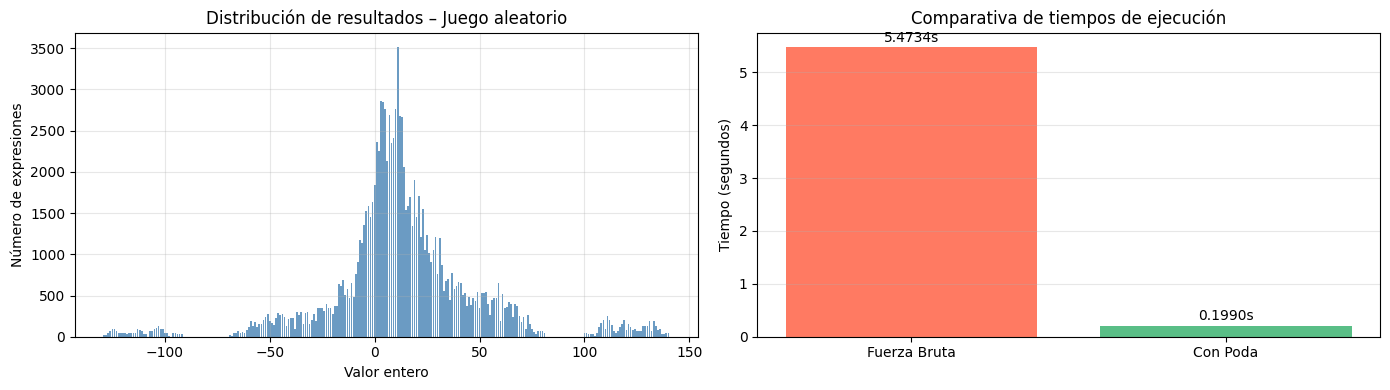

In [ ]:
# ─── Aplicar algoritmos al juego de datos aleatorio ──────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

print("=" * 60)
print(f"JUEGO DE DATOS: {juego_datos['nums']}")
print("=" * 60)

# 1. Fuerza bruta
t0 = time.time()
sol_aleatorio_fb = fuerza_bruta(nums=juego_datos['nums'], ops=juego_datos['ops'])
t1 = time.time()
tiempo_fb = t1 - t0

dct_aleatorio = {}
for e in sol_aleatorio_fb:
    r = int(eval(e))
    dct_aleatorio.setdefault(r, []).append(e)
dct_aleatorio = dict(sorted(dct_aleatorio.items()))

print(f"\n[Fuerza Bruta]")
print(f"  Expresiones enteras:  {len(sol_aleatorio_fb):,}")
print(f"  Valores distintos:    {len(dct_aleatorio)}")
print(f"  Máximo:               {max(dct_aleatorio.keys())}")
print(f"  Mínimo:               {min(dct_aleatorio.keys())}")
print(f"  Tiempo:               {tiempo_fb:.3f} s")

# 2. Con poda
t0 = time.time()
sol_aleatorio_poda = fuerza_bruta_con_poda(nums=juego_datos['nums'], ops=juego_datos['ops'])
t1 = time.time()
tiempo_poda = t1 - t0

dct_poda_al = {}
for e in sol_aleatorio_poda:
    r = int(eval(e))
    dct_poda_al.setdefault(r, []).append(e)

print(f"\n[Con Poda]")
print(f"  Expresiones evaluadas: {len(sol_aleatorio_poda):,}")
print(f"  Máximo:                {max(dct_poda_al.keys())}")
print(f"  Mínimo:                {min(dct_poda_al.keys())}")
print(f"  Tiempo:                {tiempo_poda:.4f} s")
print(f"  Aceleración:           {tiempo_fb/max(tiempo_poda,0.0001):.1f}×")

# ─── Verificar cobertura de enteros ───────────────────────────────
val_min = min(dct_aleatorio.keys())
val_max = max(dct_aleatorio.keys())
todos_enteros = set(range(val_min, val_max + 1))
encontrados   = set(dct_aleatorio.keys())
print(f"\n¿Todos los enteros [{val_min}, {val_max}] son alcanzables?  {todos_enteros == encontrados}")

# ─── Visualización ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histograma de frecuencias
x = list(dct_aleatorio.keys())
y = [len(v) for v in dct_aleatorio.values()]
axes[0].bar(x, y, color='steelblue', alpha=0.8)
axes[0].set_title('Distribución de resultados – Juego aleatorio', fontsize=12)
axes[0].set_xlabel('Valor entero')
axes[0].set_ylabel('Número de expresiones')
axes[0].grid(True, alpha=0.3)

# Comparativa de tiempos
labels = ['Fuerza Bruta', 'Con Poda']
tiempos = [tiempo_fb, tiempo_poda]
colors  = ['tomato', 'mediumseagreen']
axes[1].bar(labels, tiempos, color=colors, alpha=0.85)
axes[1].set_title('Comparativa de tiempos de ejecución', fontsize=12)
axes[1].set_ylabel('Tiempo (segundos)')
axes[1].grid(True, alpha=0.3, axis='y')
for i, t in enumerate(tiempos):
    axes[1].text(i, t + max(tiempos)*0.02, f'{t:.4f}s', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

Enumera las referencias que has utilizado(si ha sido necesario) para llevar a cabo el trabajo

**Referencias:**

1. Documentación oficial de Python — Módulo `itertools`: https://docs.python.org/3/library/itertools.html — Utilizada para las funciones `permutations` y la generación del espacio de soluciones.

2. Documentación oficial de Python — Función `eval`: https://docs.python.org/3/library/functions.html#eval — Utilizada para evaluar las expresiones matemáticas generadas como cadenas de texto.

3. Python Software Foundation. *Python 3 Documentation*. https://docs.python.org — Referencia general para el lenguaje.

4. Apuntes y materiales de la asignatura *Algoritmos de Optimización* – VIU, curso 2026.

Describe brevemente las lineas de como crees que es posible avanzar en el estudio del problema. Ten en cuenta incluso posibles variaciones del problema y/o variaciones al alza del tamaño

**Trabajo futuro:**

- Invertir el problema: partir de un valor objetivo y construir la expresión que lo alcance, en vez de generar todo y filtrar
- Paralelizar la fuerza bruta repartiendo las 24 permutaciones de operadores entre varios núcleos con `multiprocessing`, reduciendo el tiempo de ejecución proporcionalmente
- Explorar si existe algún patrón que permita predecir directamente qué combinación produce un valor dado, sin necesidad de búsqueda exhaustiva

**Variaciones del problema:**

- Cambiar la restricción de alternar cifra-operador, por ejemplo permitir dos números consecutivos para formar números de dos dígitos (12, 23...)
- Modificar la cantidad de operadores usados: no necesariamente los 4, sino elegir 3 de los 4 disponibles y ver cómo cambia el espacio de soluciones
- Incluir el cero en el conjunto de dígitos y analizar cómo afecta al espacio de soluciones, teniendo en cuenta las divisiones por cero
- Cambiar el conjunto de dígitos por uno personalizado (solo pares, solo primos, un rango distinto) y ver si la cobertura de enteros sigue siendo completa